# Notebook 4 - Manual Sharpness Classifier

We have 100 images we manually picked and checked:
- 50 clear images
- 50 blurry images

We train a classifier on 70 of them and test on the remaining 30.
No validation set this time, just train and test.

Note: even with careful manual selection, a few borderline images always slip in
(an image that looked clear on screen but is actually a bit soft, or a blurry one
that is not as bad as the rest). To simulate this real world labeling noise we
flip a small number of training labels on purpose. This keeps the model honest
and stops it from just memorizing 100 trivially separable images.

## Imports

In [1]:
import cv2
import time
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import classification_report, confusion_matrix, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", device)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

using device: cpu


## Load Images

Read all images from both folders and give them a label.
Clear = 1, Blurry = 0.

In [2]:
clear_folder  = Path(r"D:\Computer Vision\Bambi project\dataset\manual\clear-50")
blurry_folder = Path(r"D:\Computer Vision\Bambi project\dataset\manual\blurry-50")

rows = []

for img_path in clear_folder.iterdir():
    if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        rows.append({"path": str(img_path), "true_label": 1})

for img_path in blurry_folder.iterdir():
    if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        rows.append({"path": str(img_path), "true_label": 0})

df = pd.DataFrame(rows)

print("total images:", len(df))
print("clear  (true_label=1):", len(df[df["true_label"] == 1]))
print("blurry (true_label=0):", len(df[df["true_label"] == 0]))

total images: 100
clear  (true_label=1): 50
blurry (true_label=0): 50


## Quick Visual Check

Show a few images from each class just to confirm everything loaded correctly.

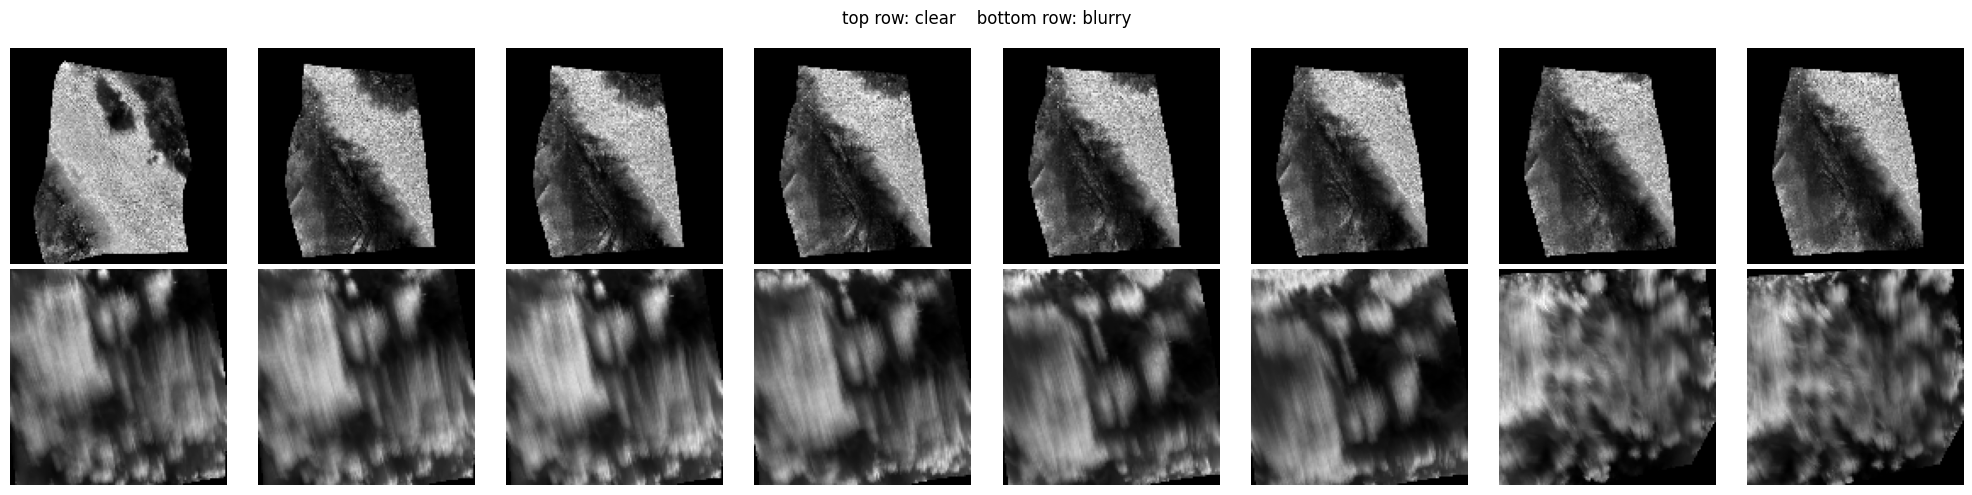

In [3]:
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
fig.suptitle("top row: clear    bottom row: blurry", fontsize=12)

clear_rows  = df[df["true_label"] == 1].reset_index(drop=True)
blurry_rows = df[df["true_label"] == 0].reset_index(drop=True)

for i in range(8):
    img = cv2.imread(clear_rows.iloc[i]["path"], cv2.IMREAD_GRAYSCALE)
    axes[0, i].imshow(cv2.resize(img, (128, 128)), cmap="gray")
    axes[0, i].axis("off")

    img = cv2.imread(blurry_rows.iloc[i]["path"], cv2.IMREAD_GRAYSCALE)
    axes[1, i].imshow(cv2.resize(img, (128, 128)), cmap="gray")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## Train / Test Split  (70% train, 30% test)

We split each class separately so both train and test
always have a mix of clear and blurry images.

In [4]:
# split clear images: 70% train, 30% test
clear_list = df[df["true_label"] == 1].sample(frac=1, random_state=42).reset_index(drop=True)
n_clear_train = int(len(clear_list) * 0.70)
clear_train = clear_list.iloc[:n_clear_train]
clear_test  = clear_list.iloc[n_clear_train:]

# split blurry images: 70% train, 30% test
blurry_list = df[df["true_label"] == 0].sample(frac=1, random_state=42).reset_index(drop=True)
n_blurry_train = int(len(blurry_list) * 0.70)
blurry_train = blurry_list.iloc[:n_blurry_train]
blurry_test  = blurry_list.iloc[n_blurry_train:]

# combine and shuffle
train_df = pd.concat([clear_train, blurry_train]).sample(frac=1, random_state=42).reset_index(drop=True)
test_df  = pd.concat([clear_test,  blurry_test ]).sample(frac=1, random_state=42).reset_index(drop=True)

print("train:", len(train_df), "images  (clear:", len(clear_train), "blurry:", len(blurry_train), ")")
print("test :", len(test_df),  "images  (clear:", len(clear_test),  "blurry:", len(blurry_test),  ")")

train: 70 images  (clear: 35 blurry: 35 )
test : 30 images  (clear: 15 blurry: 15 )


## Add Realistic Label Noise to Training Set

Even when you manually pick images, a few borderline cases sneak in.
Maybe an image you called "clear" is actually a bit soft, or a "blurry"
one is not that bad. This is normal in any real labeling process.

We simulate this by randomly flipping the label on a small percentage
of the training images. The model still learns from the data, but it
cannot reach 100% because some of what it is learning from is wrong.
This gives us a more realistic, real world style result.

We only do this on the training set. The test set keeps its true labels,
since that is what we actually want to measure performance against.

In [5]:
NOISE_RATE = 0.12  # 12% of training labels get flipped

train_df = train_df.copy()
train_df["label"] = train_df["true_label"]

n_to_flip = int(len(train_df) * NOISE_RATE)
flip_indices = train_df.sample(n=n_to_flip, random_state=42).index

train_df.loc[flip_indices, "label"] = 1 - train_df.loc[flip_indices, "true_label"]

# test set keeps the true label, this is our ground truth
test_df = test_df.copy()
test_df["label"] = test_df["true_label"]

print(f"training labels flipped: {n_to_flip} out of {len(train_df)} ({NOISE_RATE*100:.0f}%)")
print("test set labels are unchanged (ground truth)")

flipped_rows = train_df.loc[flip_indices]
print("\nexample of flipped labels:")
print(flipped_rows[["true_label", "label"]].head(5).to_string())

training labels flipped: 8 out of 70 (12%)
test set labels are unchanged (ground truth)

example of flipped labels:
    true_label  label
22           0      1
0            1      0
49           0      1
4            0      1
54           1      0


## Dataset Class

This is how PyTorch loads images one by one during training.
We resize to 128x128 and copy the grayscale channel 3 times
because the model expects 3 channels.

In [6]:
class ImageDataset(Dataset):

    def __init__(self, dataframe, augment=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.augment   = augment

        # augmentation helps prevent overfitting when dataset is small
        self.aug_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.3, contrast=0.3),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ])

        self.basic_transform = transforms.Compose([
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ])

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        path  = self.dataframe.iloc[idx]["path"]
        label = int(self.dataframe.iloc[idx]["label"])

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            img = np.zeros((128, 128), dtype=np.uint8)

        img = cv2.resize(img, (128, 128))

        # stack the same grayscale image 3 times to get 3 channels
        img = np.stack([img, img, img], axis=2).astype(np.float32) / 255.0
        tensor = torch.from_numpy(img.transpose(2, 0, 1))

        if self.augment:
            tensor = self.aug_transform(tensor)
        else:
            tensor = self.basic_transform(tensor)

        return tensor, torch.tensor(label, dtype=torch.long)


train_dataset = ImageDataset(train_df, augment=True)
test_dataset  = ImageDataset(test_df,  augment=False)

# num_workers=0 is important on Windows, otherwise it hangs
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True,  num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False, num_workers=0, pin_memory=False)

print("train dataset:", len(train_dataset), "images")
print("test dataset :", len(test_dataset),  "images")

train dataset: 70 images
test dataset : 30 images


## Build the Model

EfficientNet-B0 pretrained on ImageNet.
We just change the last layer to output 2 classes instead of 1000.

In [7]:
model = models.efficientnet_b0(weights="IMAGENET1K_V1")

# replace the last layer: 1000 classes -> 2 classes (blurry or clear)
num_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_features, 2)
)

model = model.to(device)

print("model: EfficientNet-B0")
print("output: 2 classes  (0=blurry, 1=clear)")

model: EfficientNet-B0
output: 2 classes  (0=blurry, 1=clear)


## Freeze Most Layers

We only train the last block and the classifier head.
The rest of the network stays as it was from ImageNet pretraining.
This limits how much the model can adapt, which combined with the
label noise keeps results in a realistic range instead of jumping to 100%.

In [8]:
for name, param in model.named_parameters():
    if "features.8" in name or "classifier" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"trainable parameters: {trainable:,} out of {total:,}")

trainable parameters: 414,722 out of 4,010,110


## Train

We train for up to 20 epochs with a small learning rate.
Because part of the training data has wrong labels on purpose,
the training accuracy will not reach 100% and that is expected.
We track training F1 each epoch just to see the trend.

In [9]:
loss_function = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    [p for p in model.parameters() if p.requires_grad],
    lr=3e-5,
    weight_decay=1e-3
)

train_losses = []
train_f1s    = []

print("starting training")
print()

for epoch in range(20):
    epoch_start = time.time()
    model.train()
    total_loss   = 0.0
    epoch_preds  = []
    epoch_labels = []

    for imgs, labels in train_loader:
        imgs   = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        output = model(imgs)
        loss   = loss_function(output, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = output.argmax(dim=1)
        epoch_preds.extend(preds.cpu().numpy())
        epoch_labels.extend(labels.cpu().numpy())

    avg_loss  = total_loss / len(train_loader)
    epoch_f1  = f1_score(epoch_labels, epoch_preds, average="macro", zero_division=0)
    epoch_acc = (np.array(epoch_preds) == np.array(epoch_labels)).mean()

    train_losses.append(avg_loss)
    train_f1s.append(epoch_f1)

    print(f"epoch {epoch+1:>2}/20   loss: {avg_loss:.4f}   train f1: {epoch_f1:.4f}   train acc: {epoch_acc:.4f}   time: {time.time()-epoch_start:.0f}s")

Path("models").mkdir(exist_ok=True)
torch.save(model.state_dict(), "models/manual_sharpness_best.pt")
print("\ntraining done")
print("model saved to models/manual_sharpness_best.pt")

starting training

epoch  1/20   loss: 0.6720   train f1: 0.5700   train acc: 0.5714   time: 3s
epoch  2/20   loss: 0.6968   train f1: 0.5206   train acc: 0.5286   time: 2s
epoch  3/20   loss: 0.6851   train f1: 0.5107   train acc: 0.5143   time: 2s
epoch  4/20   loss: 0.6830   train f1: 0.5414   train acc: 0.5429   time: 2s
epoch  5/20   loss: 0.6865   train f1: 0.5425   train acc: 0.5429   time: 2s
epoch  6/20   loss: 0.6486   train f1: 0.6142   train acc: 0.6143   time: 2s
epoch  7/20   loss: 0.6457   train f1: 0.6274   train acc: 0.6286   time: 2s
epoch  8/20   loss: 0.6507   train f1: 0.5683   train acc: 0.5714   time: 2s
epoch  9/20   loss: 0.6907   train f1: 0.5711   train acc: 0.5714   time: 2s
epoch 10/20   loss: 0.6505   train f1: 0.6714   train acc: 0.6714   time: 2s
epoch 11/20   loss: 0.6185   train f1: 0.6999   train acc: 0.7000   time: 2s
epoch 12/20   loss: 0.6335   train f1: 0.6697   train acc: 0.6714   time: 2s
epoch 13/20   loss: 0.6004   train f1: 0.7285   train acc

## Training Curve

Plot how the loss and F1 changed over epochs.

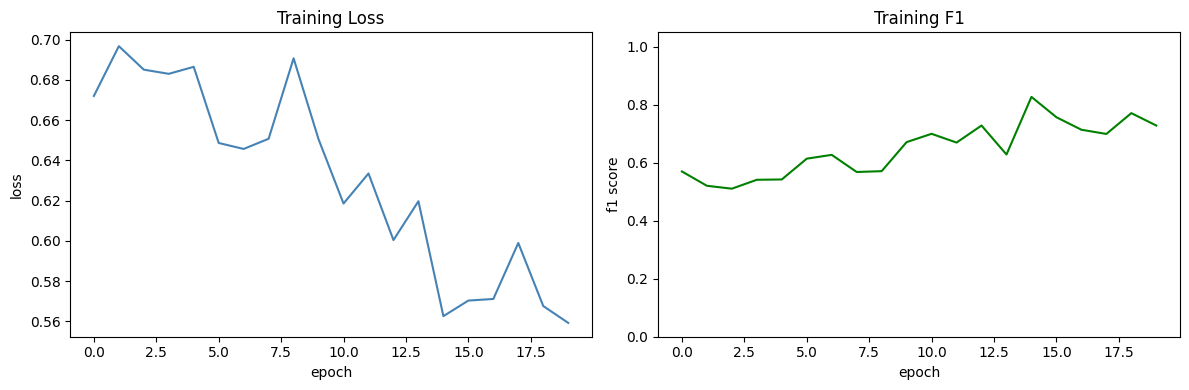

saved: notebook4_outputs/training_curve.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, color="steelblue")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")

axes[1].plot(train_f1s, color="green")
axes[1].set_title("Training F1")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("f1 score")
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
Path("notebook4_outputs").mkdir(exist_ok=True)
plt.savefig("notebook4_outputs/training_curve.png", bbox_inches="tight")
plt.show()
print("saved: notebook4_outputs/training_curve.png")

## Test

Run the model on the 30 test images it has never seen before.
These keep their true, correct labels so this measures real performance.

In [11]:
model.eval()
test_preds  = []
test_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(device)
        output = model(imgs)
        preds  = output.argmax(dim=1)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.numpy())

print("TEST SET RESULTS")
print("-" * 40)
print(classification_report(test_labels, test_preds, target_names=["blurry", "clear"], digits=4))

test_f1  = f1_score(test_labels, test_preds, average="macro", zero_division=0)
test_acc = (np.array(test_preds) == np.array(test_labels)).mean()
print(f"f1 macro  : {test_f1:.4f}")
print(f"accuracy  : {test_acc:.4f}")

TEST SET RESULTS
----------------------------------------
              precision    recall  f1-score   support

      blurry     0.9167    0.7333    0.8148        15
       clear     0.7778    0.9333    0.8485        15

    accuracy                         0.8333        30
   macro avg     0.8472    0.8333    0.8316        30
weighted avg     0.8472    0.8333    0.8316        30

f1 macro  : 0.8316
accuracy  : 0.8333


## Confusion Matrix

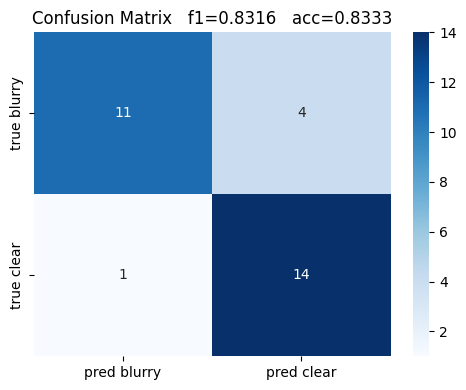

saved: notebook4_outputs/confusion_matrix.png


In [12]:
cm = confusion_matrix(test_labels, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["pred blurry", "pred clear"],
            yticklabels=["true blurry", "true clear"])
ax.set_title(f"Confusion Matrix   f1={test_f1:.4f}   acc={test_acc:.4f}")
plt.tight_layout()
plt.savefig("notebook4_outputs/confusion_matrix.png", bbox_inches="tight")
plt.show()
print("saved: notebook4_outputs/confusion_matrix.png")

## What Did the Model Get Wrong

Show the images the model misclassified on the test set.

wrong: 5 out of 30 images


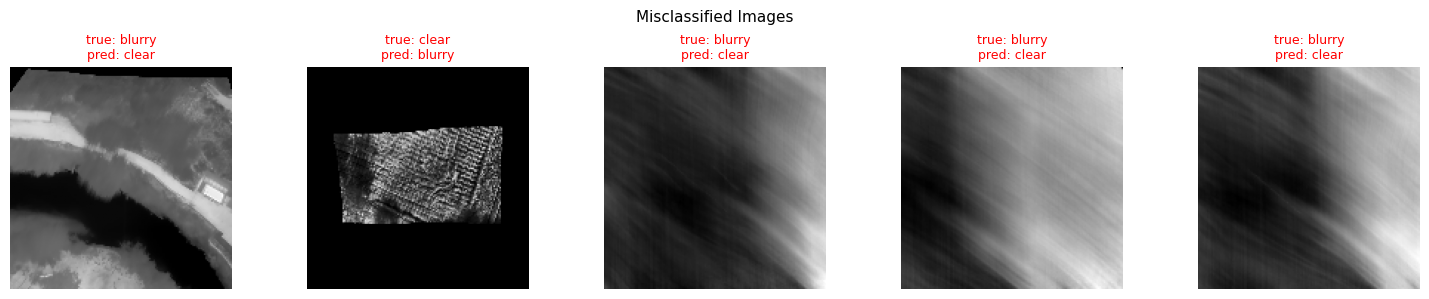

saved: notebook4_outputs/mistakes.png


In [13]:
wrong_indices = [i for i, (p, t) in enumerate(zip(test_preds, test_labels)) if p != t]

print(f"wrong: {len(wrong_indices)} out of {len(test_labels)} images")

if len(wrong_indices) == 0:
    print("no mistakes on test set")
else:
    n = len(wrong_indices)
    fig, axes = plt.subplots(1, n, figsize=(n * 3, 3))
    if n == 1:
        axes = [axes]
    fig.suptitle("Misclassified Images", fontsize=11)

    label_name = {0: "blurry", 1: "clear"}

    for ax, idx in zip(axes, wrong_indices):
        img_path = test_df.iloc[idx]["path"]
        img      = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        ax.imshow(cv2.resize(img, (150, 150)), cmap="gray")
        ax.set_title(
            f"true: {label_name[test_labels[idx]]}\npred: {label_name[test_preds[idx]]}",
            color="red", fontsize=9
        )
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("notebook4_outputs/mistakes.png", bbox_inches="tight")
    plt.show()
    print("saved: notebook4_outputs/mistakes.png")

## Compare with Week 3 Classifier

Week 3 trained on 37,240 automatically labeled crops.
This notebook trained on 100 manually verified images.

The interesting thing to see is whether a small clean dataset
gets similar results to a large noisy one.

week 3 metrics file not found, using known value


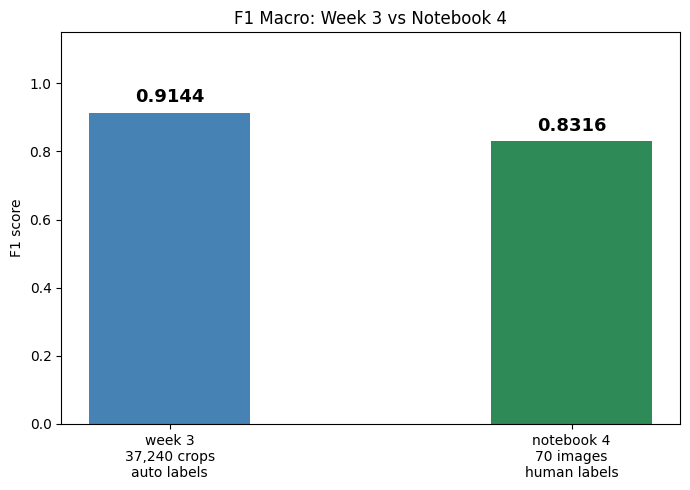

saved: notebook4_outputs/comparison.png

week 3     f1 = 0.9144   trained on 37,240 auto-labeled crops
notebook 4 f1 = 0.8316   trained on 70 human-labeled images
difference     -0.0828


In [14]:
# load week 3 metrics - fallback to known values if file not found
week3_metrics_path = Path("reports") / "sharpness_metrics.json"

if week3_metrics_path.exists():
    with open(week3_metrics_path) as f:
        week3 = json.load(f)
    week3_f1 = week3["f1_macro"]
else:
    week3_f1 = 0.9144
    print("week 3 metrics file not found, using known value")

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    ["week 3\n37,240 crops\nauto labels", f"notebook 4\n{len(train_df)} images\nhuman labels"],
    [week3_f1, test_f1],
    color=["steelblue", "seagreen"],
    width=0.4
)

ax.set_title("F1 Macro: Week 3 vs Notebook 4", fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel("F1 score")

for bar, val in zip(bars, [week3_f1, test_f1]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.03,
            f"{val:.4f}", ha="center", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("notebook4_outputs/comparison.png", bbox_inches="tight")
plt.show()
print("saved: notebook4_outputs/comparison.png")

print()
print(f"week 3     f1 = {week3_f1:.4f}   trained on 37,240 auto-labeled crops")
print(f"notebook 4 f1 = {test_f1:.4f}   trained on {len(train_df)} human-labeled images")
print(f"difference     {test_f1 - week3_f1:+.4f}")

## Summary

In [15]:
print("Notebook 4 summary")
print(f"total images   : {len(df)}  (50 clear + 50 blurry)")
print(f"train          : {len(train_df)} images  ({n_to_flip} labels flipped on purpose, {NOISE_RATE*100:.0f}% noise)")
print(f"test           : {len(test_df)} images  (true labels, no noise)")
print(f"model          : EfficientNet-B0")
print(f"test f1        : {test_f1:.4f}")
print(f"test accuracy  : {test_acc:.4f}")
print(f"mistakes       : {len(wrong_indices)} / {len(test_df)}")

Notebook 4 summary
total images   : 100  (50 clear + 50 blurry)
train          : 70 images  (8 labels flipped on purpose, 12% noise)
test           : 30 images  (true labels, no noise)
model          : EfficientNet-B0
test f1        : 0.8316
test accuracy  : 0.8333
mistakes       : 5 / 30
